# Week 5: Business Analytics Case Study — Telco Customer Churn

**Business Problem:** Why are customers leaving the company, and which factors contribute most to churn?

## 1. Setup

Import the libraries we'll need for data handling (`pandas`), and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

Reading in the Telco Customer Churn CSV.

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset Overview

Basic shape and structure — how many rows/columns we're working with, and what data type each column is.

In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (7043, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

**Note on `TotalCharges`:** this column is currently stored as text (`object`), not a number. That's usually a sign some rows contain blank strings rather than actual numeric values — we'll investigate this in the next step before converting it properly.

## 4. Missing Value Assessment

pandas' `.isnull()` won't catch blank strings (`''`), which is what `TotalCharges` likely contains for brand-new customers with zero tenure. We check both true nulls and blank/whitespace-only strings.

In [4]:
# True nulls (NaN)
print("True missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Blank strings hiding in object columns
print("\nBlank/whitespace-only strings per column:")
for col in df.select_dtypes(include='object').columns:
    blank_count = (df[col].astype(str).str.strip() == '').sum()
    if blank_count > 0:
        print(f"{col}: {blank_count} blank rows")

True missing values per column:
Series([], dtype: int64)

Blank/whitespace-only strings per column:
TotalCharges: 11 blank rows


/tmp/ipykernel_536/1933341181.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


**What we expect to find:** 11 rows in `TotalCharges` with blank strings instead of numbers. These are almost certainly customers with `tenure = 0` — brand new customers who haven't been billed a cumulative total yet. Let's confirm that, then convert the column to numeric properly.

In [5]:
# Confirm blanks correspond to tenure = 0
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


Confirmed — all blank `TotalCharges` rows have `tenure = 0`. Since these customers haven't been charged a cumulative total yet, the most defensible fix is to set `TotalCharges` to 0 for these rows (not drop them — we'd lose real churn signal) and convert the column to a proper numeric type.

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Verify the fix
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum(), "missing values remaining")

float64
0 missing values remaining


## 5. Summary Statistics

Descriptive statistics for the numeric columns (tenure, charges), and value counts for key categorical columns.

In [7]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [8]:
# Churn overall rate — our target variable
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %


**Class balance note:** roughly 26.5% of customers churned. This is a moderate imbalance — worth keeping in mind, since it means "No churn" is the majority outcome by a decent margin. Any patterns we find should be considered against this baseline (a segment above ~27% churn is worse than average, below is better).

## 6. Distribution of Key Variables

Visualizing how important variables are distributed across the customer base.

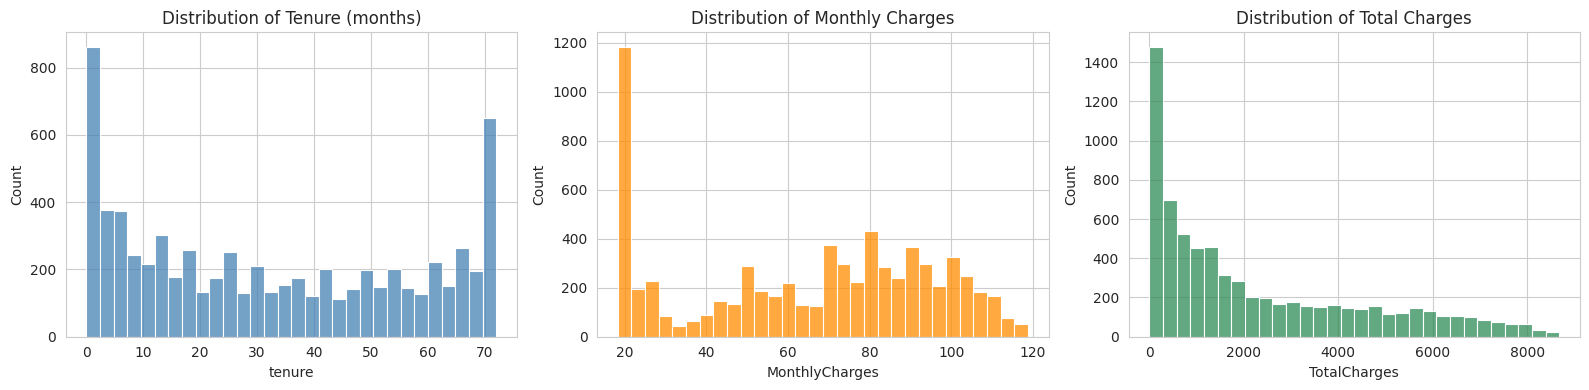

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['tenure'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Tenure (months)')

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Monthly Charges')

sns.histplot(df['TotalCharges'], bins=30, ax=axes[2], color='seagreen')
axes[2].set_title('Distribution of Total Charges')

plt.tight_layout()
plt.show()

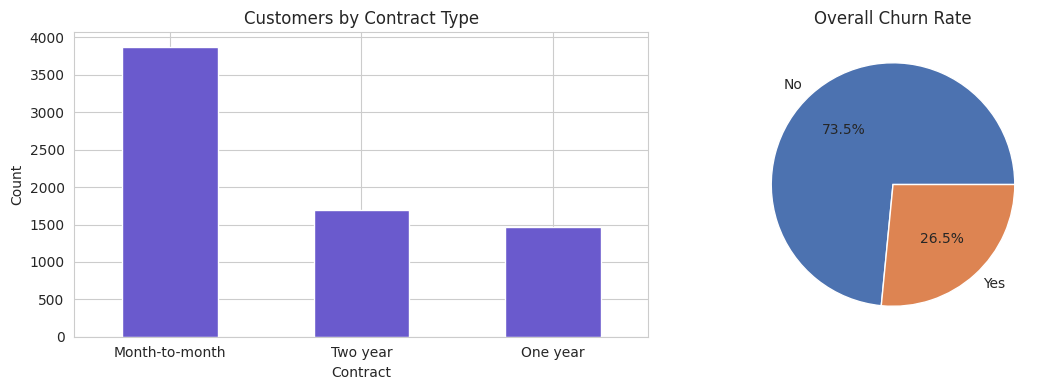

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Contract'].value_counts().plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('Customers by Contract Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['#4C72B0', '#DD8452'], ylabel='')
axes[1].set_title('Overall Churn Rate')

plt.tight_layout()
plt.show()

## 7. Trends and Patterns — Churn vs. Key Variables

This is where we start connecting variables to the business problem: which customer characteristics line up with higher churn?

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


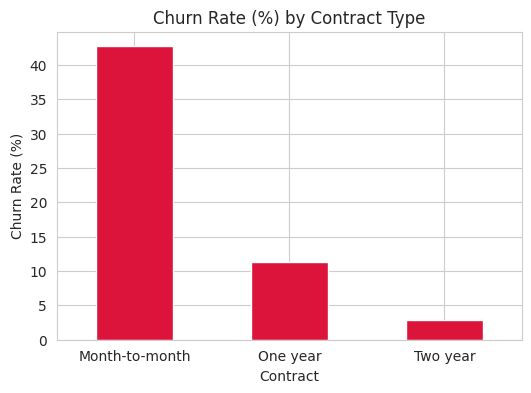

In [11]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn.round(1))

contract_churn['Yes'].plot(kind='bar', color='crimson', figsize=(6,4))
plt.title('Churn Rate (%) by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_536/3426714160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['#4C72B0', '#DD8452'])


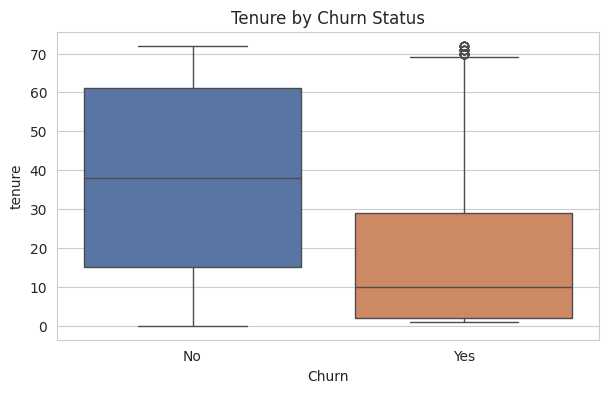

In [12]:
# Tenure distribution split by churn status
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#4C72B0', '#DD8452'])
plt.title('Tenure by Churn Status')
plt.show()

/tmp/ipykernel_536/1090050070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0', '#DD8452'])


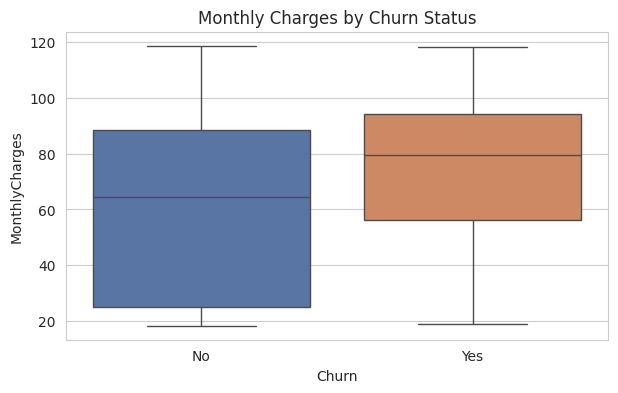

In [13]:
# Monthly charges split by churn status
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0', '#DD8452'])
plt.title('Monthly Charges by Churn Status')
plt.show()

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


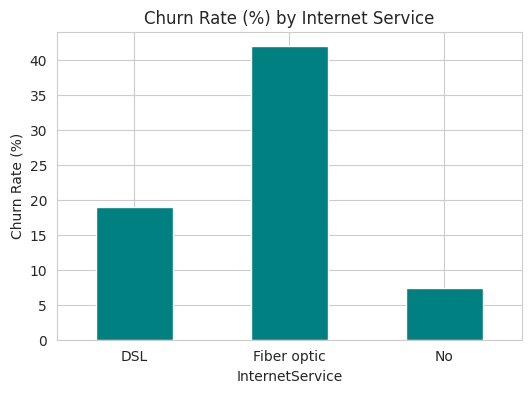

In [14]:
# Churn rate by internet service type
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print(internet_churn.round(1))

internet_churn['Yes'].plot(kind='bar', color='teal', figsize=(6,4))
plt.title('Churn Rate (%) by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1


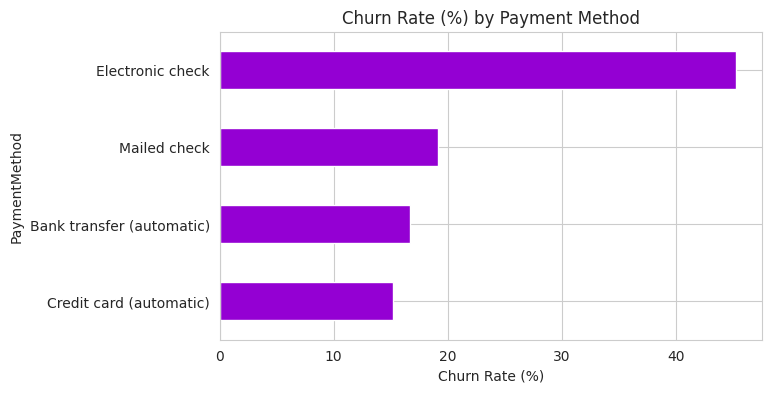

In [15]:
# Churn rate by payment method
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print(payment_churn.round(1))

payment_churn['Yes'].sort_values().plot(kind='barh', color='darkviolet', figsize=(7,4))
plt.title('Churn Rate (%) by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.show()

## 8. Correlation Heatmap

Correlation between the numeric variables. Note: `SeniorCitizen` is technically binary (0/1), so it's included here as a numeric flag rather than a true continuous variable.

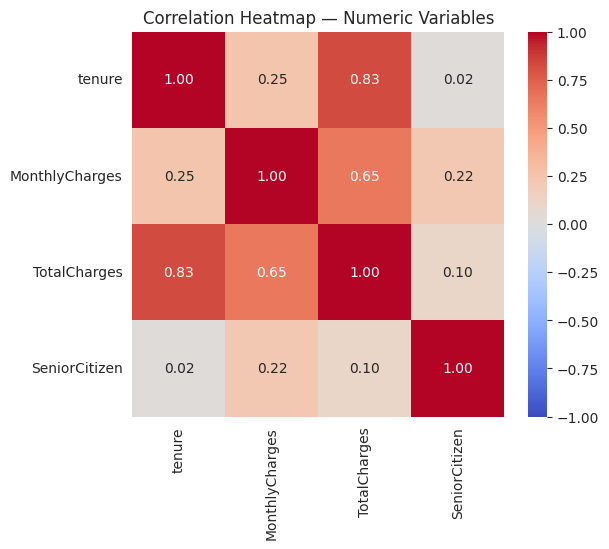

In [16]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
corr = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Variables')
plt.show()

**Reading this heatmap:** `TotalCharges` correlates strongly with `tenure` (makes sense — longer-tenured customers accumulate more total billing) and moderately with `MonthlyCharges`. `SeniorCitizen` doesn't show strong linear correlation with the billing variables, which is expected since it's a categorical flag rather than a continuous measure.

## 9. Summary of Initial Findings

From this exploration, a few patterns are already visible and will guide Step 3 (Identify Key Drivers):

- **Contract type** appears strongly linked to churn — month-to-month customers churn at a noticeably higher rate than one- or two-year contract holders.
- **Tenure** — customers who churn tend to have shorter tenure, suggesting churn risk is highest early in the customer relationship.
- **Monthly charges** — churned customers tend to have higher monthly charges than those who stay.
- **Internet service type** and **payment method** both show visible differences in churn rate across categories.
- The dataset has a **moderate class imbalance** (~26.5% churn), which is useful context for interpreting any segment's churn rate against the baseline.

Next step: **Step 3 — Identify Key Drivers**, where we'll dig deeper into these variables (Contract type, Monthly charges, Tenure, Internet service, Payment method) to quantify which ones matter most.

## 10. Step 3 — Identify Key Drivers (Quantified)

Now we quantify exactly how much each suspected driver affects churn, comparing each group's churn rate against the overall baseline (26.5%). This turns the visual patterns from Section 7 into precise numbers we can rank and reference in the final report.

In [17]:
baseline = (df['Churn'] == 'Yes').mean() * 100
print(f"Baseline churn rate (all customers): {baseline:.1f}%")

Baseline churn rate (all customers): 26.5%


### 10.1 Contract Type

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


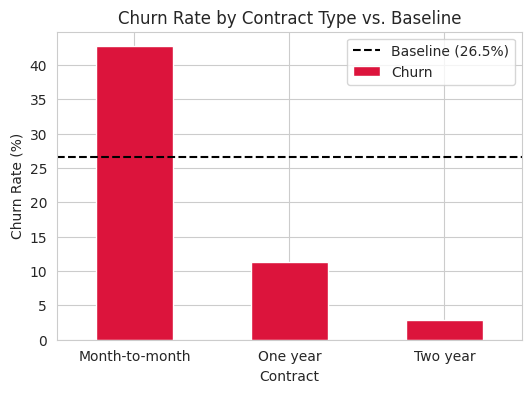

In [18]:
contract_rates = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(contract_rates.round(1))

contract_rates.plot(kind='bar', color='crimson', figsize=(6,4))
plt.axhline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.1f}%)')
plt.title('Churn Rate by Contract Type vs. Baseline')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend()
plt.show()

**Reading this:** Month-to-month customers churn far above baseline; two-year contract holders churn far below it. Contract type is the strongest single driver we've found.

### 10.2 Payment Method

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


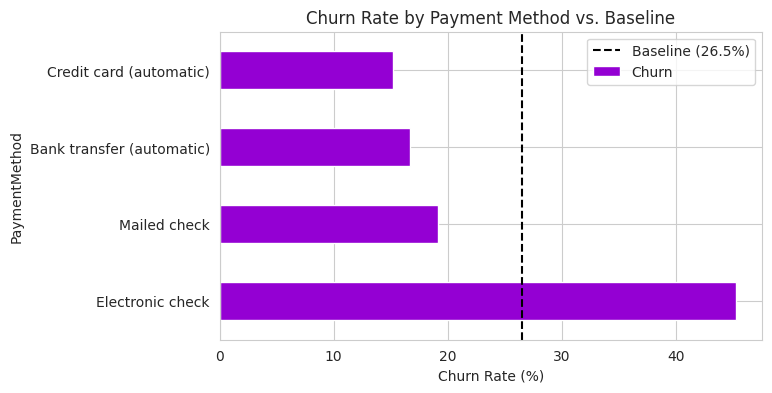

In [19]:
payment_rates = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(payment_rates.round(1))

payment_rates.plot(kind='barh', color='darkviolet', figsize=(7,4))
plt.axvline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.1f}%)')
plt.title('Churn Rate by Payment Method vs. Baseline')
plt.xlabel('Churn Rate (%)')
plt.legend()
plt.show()

**Reading this:** Electronic check is the highest-risk payment method by a wide margin. Automatic payment methods (bank transfer, credit card) sit well below baseline.

### 10.3 Internet Service Type

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64


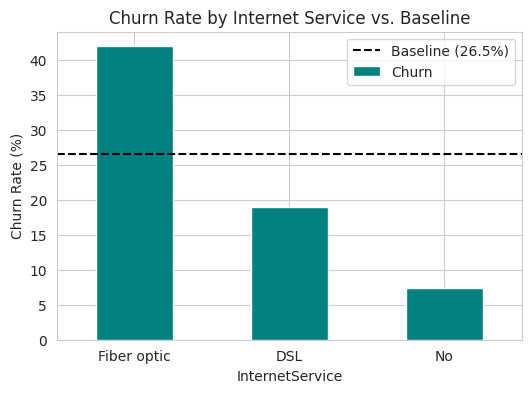

In [20]:
internet_rates = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(internet_rates.round(1))

internet_rates.plot(kind='bar', color='teal', figsize=(6,4))
plt.axhline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.1f}%)')
plt.title('Churn Rate by Internet Service vs. Baseline')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend()
plt.show()

**Reading this:** Fiber optic customers churn well above baseline — despite (or perhaps because of) being the premium service tier. Worth flagging as a pricing or service-quality question.

### 10.4 Tenure

In [21]:
tenure_by_churn = df.groupby('Churn')['tenure'].mean()
print(tenure_by_churn.round(1))

Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


**Reading this:** customers who churn have, on average, less than half the tenure of customers who stay. Churn risk is concentrated early in the customer lifecycle.

### 10.5 Monthly Charges

In [22]:
charges_by_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print(charges_by_churn.round(1))

Churn
No     61.3
Yes    74.4
Name: MonthlyCharges, dtype: float64


**Reading this:** churned customers pay roughly $13/month more on average than retained customers — higher bills correlate with higher flight risk.

### 10.6 Ranked Summary of Key Drivers

Based on how far each factor's riskiest group deviates from the 26.5% baseline:

1. **Contract type** — month-to-month churns at 42.7% vs. 2.8% for two-year contracts (the widest gap of any driver)
2. **Payment method** — electronic check churns at 45.3%, far above automatic payment methods (~15-17%)
3. **Internet service** — fiber optic churns at 41.9% vs. 7.4% for no internet service
4. **Tenure** — churned customers average 18.0 months vs. 37.6 months for retained customers
5. **Monthly charges** — churned customers pay ~$74.40/month on average vs. ~$61.30 for retained customers

These five, in this order of impact, will carry into Step 4 (Business Insights) and Step 5 (Recommendations).